# GSA-VLN: Using Semantics
## GSA-VLN (Paper Eq.3) vs GSA-VLN + Semantic Adaptation (Your Contribution)

### Experimental Setup
Both methods share **identical** pretrained weights (theta_0), real R2R data, supervised imitation learning (3 epochs), and eval protocol.

| Method | Model | Adaptation Loop |
|--------|-------|-----------------|
| **GSA-VLN** | Standard | Eq.3: TC(0.5) + ENT(0.3) + REC(0.2) |
| **GSA-VLN + Semantic** | Semantic-aware | Eq.3 + Semantic Contrastive Loss: TC(0.4) + ENT(0.25) + REC(0.15) + SEM(0.20) |

### Contribution
Adds a **4th loss** to the Eq.3 adaptation step: **Semantic Contrastive Loss** (InfoNCE) that aligns the instruction's room-type language embedding with matching visual viewpoints in the accumulated GraphMap. The semantic model also uses room-type-aware graph attention during both training and adaptation.


## 📦 Dataset Setup — Download R2R Data from VLN-DUET (Dropbox)

This notebook requires three things: **annotations**, **connectivity graphs**, and **ViT visual features**.  
All of them come from the [VLN-DUET repository](https://github.com/cshizhe/VLN-DUET/tree/main) (Chen et al., CVPR 2022), which hosts a Dropbox bundle used across the VLN community.


## Section 1: Installation & Setup


In [ ]:
# Install required packages
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
    "numpy", "pandas", "matplotlib", "seaborn",
    "networkx", "tqdm", "scipy", "h5py", "transformers", "scikit-learn"])
print("Dependencies ready.")

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import json
import h5py
import networkx as nx
from collections import defaultdict, deque
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Tuple, Optional
import random
import copy
from dataclasses import dataclass, field
from pathlib import Path
import math

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch : {torch.__version__}")
print(f"Device  : {device}")
if torch.cuda.is_available():
    name = torch.cuda.get_device_name(0)
    cap  = torch.cuda.get_device_capability(0)
    mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU     : {name}  (sm_{cap[0]}{cap[1]},  {mem:.1f} GB)")
    try:
        _ = torch.zeros(2, device="cuda") + 1
        print("CUDA    : OK")
    except Exception as e:
        print(f"CUDA    : FAILED — {e}")
        device = torch.device("cpu")
else:
    print("No CUDA GPU — running on CPU.")


Dependencies ready.
PyTorch : 2.10.0+cu128
Device  : cuda
GPU     : Tesla P100-PCIE-16GB  (sm_60,  17.1 GB)
CUDA    : FAILED — CUDA error: no kernel image is available for execution on the device
Search for `cudaErrorNoKernelImageForDevice' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.



/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 Tesla P100-PCIE-16GB which is of cuda capability 6.0.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (7.0) - (12.0)
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Please install PyTorch with a following CUDA
    configurations:  12.6 following instructions at
    https://pytorch.org/get-started/locally/
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
Tesla P100-PCIE-16GB with CUDA capability sm_60 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_70 sm_75 sm_80 sm_86 sm_90 sm_100 sm_120.
If you want to use the Tesla P100-PCIE-16GB GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  queued_call()


## Section 2: Real Data Loading — NavigationGraph, SemanticGraphMap, MemoryBank

**Real Data Integration:**
- `NavigationGraph` built from actual Matterport3D connectivity JSON files
- Visual features loaded from ViT-Base HDF5 file (auto-detected dim, typically 1768)
- `R2RDataset` loads real R2R instruction-path pairs with natural train/val split
- Room types inferred from instruction keywords (real scans don't have ground-truth labels)


In [ ]:
# =============================================================================
# CONFIG — SET YOUR PATHS HERE
# =============================================================================
ANNO_DIR  = '/kaggle/input/datasets/mobin555/gsa-r2r/annotations/'
CONN_DIR  = '/kaggle/input/datasets/mobin555/gsa-r2r/connectivity/'
FEAT_PATH = '/kaggle/input/datasets/mobin555/gsa-r2r/features/pth_vit_base_patch16_224_imagenet.hdf5'

TRAIN_FILE = ANNO_DIR + 'R2R_train_enc.json'
VAL_FILE   = ANNO_DIR + 'R2R_val_seen_enc.json'

HIDDEN_DIM    = 256
MAX_INSTR_LEN = 80

# =============================================================================
# FEATURE FILE — auto-detect FEATURE_DIM (Bug Fix #2: was hardcoded 512)
# =============================================================================
print('Opening feature file...')
feature_store = h5py.File(FEAT_PATH, 'r')
sample_key    = list(feature_store.keys())[0]
sample_feat   = feature_store[sample_key][:]
FEATURE_DIM   = int(sample_feat.shape[-1])
print(f'  Feature file OK. Key: {sample_key!r}, shape: {sample_feat.shape}')
print(f'  FEATURE_DIM auto-set to {FEATURE_DIM}')

# =============================================================================
# SEMANTIC VOCABULARY — maps instruction words to room type indices
# Room types are inferred from instruction text (real data has no room-type GT)
# =============================================================================
ROOM_TYPES = {
    0: 'kitchen',
    1: 'bedroom',
    2: 'bathroom',
    3: 'hallway',
    4: 'living_room',
    5: 'office',
    6: 'corridor',
    7: 'entrance',
}

SEMANTIC_VOCABULARY = {
    'kitchen': 0, 'cook': 0, 'stove': 0, 'fridge': 0, 'refrigerator': 0,
    'bedroom': 1, 'sleep': 1, 'bed': 1,
    'bathroom': 2, 'bath': 2, 'toilet': 2, 'sink': 2, 'shower': 2,
    'hallway': 3, 'hall': 3,
    'living': 4, 'room': 4, 'sofa': 4, 'couch': 4,
    'office': 5, 'desk': 5,
    'corridor': 6,
    'entrance': 7, 'enter': 7, 'door': 7, 'exit': 7,
}

# =============================================================================
# HELPERS
# =============================================================================
def load_connectivity(scan_id: str):
    """Load Matterport3D connectivity for a scan, return adjacency + positions."""
    path = f'{CONN_DIR}{scan_id}_connectivity.json'
    with open(path, 'r') as f:
        conn = json.load(f)
    adjacency = defaultdict(list)
    positions  = {}
    for node in conn:
        if not node.get('included', True):
            continue
        vp   = node['image_id']
        pose = node.get('pose', [0]*16)
        positions[vp] = {'x': pose[3], 'y': pose[7], 'z': pose[11]}
        for i, unob in enumerate(node.get('unobstructed', [])):
            if unob and i < len(conn):
                nb_vp = conn[i]['image_id']
                if nb_vp != vp:
                    adjacency[vp].append(nb_vp)
    return dict(adjacency), positions


def get_view_feature(viewpoint_id: str) -> np.ndarray:
    """Mean-pool 36 ViT views → (FEATURE_DIM,). Zero-vector if key missing."""
    try:
        return feature_store[viewpoint_id][:].mean(axis=0).astype(np.float32)
    except KeyError:
        return np.zeros(FEATURE_DIM, dtype=np.float32)


def infer_room_type(instruction: str) -> int:
    """Infer dominant room type from instruction text."""
    instr_lower = instruction.lower()
    for word, rt in SEMANTIC_VOCABULARY.items():
        if word in instr_lower:
            return rt
    return 0  # default: kitchen / unknown


# =============================================================================
# NavigationGraph — REAL: built from Matterport3D connectivity files
# =============================================================================
class NavigationGraph:
    """Real scene graph from Matterport3D connectivity JSON."""
    def __init__(self, scan_id: str):
        self.graph_id        = scan_id
        self.adjacency, self.node_positions = load_connectivity(scan_id)
        self.nodes = set(self.adjacency.keys()) | {
            nb for nbs in self.adjacency.values() for nb in nbs}
        self.graph = nx.Graph()
        for vp, neighbors in self.adjacency.items():
            for nb in neighbors:
                self.graph.add_edge(vp, nb)

        # Node features loaded lazily from HDF5 on first call
        self._feature_cache: Dict[str, np.ndarray] = {}

    def get_neighbors(self, vp: str) -> List[str]:
        return self.adjacency.get(vp, [])

    def get_feature(self, vp: str) -> np.ndarray:
        if vp not in self._feature_cache:
            self._feature_cache[vp] = get_view_feature(vp)
        return self._feature_cache[vp]

    def get_position(self, vp: str) -> Dict:
        return self.node_positions.get(vp, {'x': 0.0, 'y': 0.0, 'z': 0.0})

    def get_room_type(self, vp: str) -> int:
        """Real data has no per-viewpoint room labels — return 0 (unknown).
        Semantic signal comes from the instruction text, not the viewpoint."""
        return 0

    def get_fixed_start(self) -> str:
        """Stable reference node (sorted) for cross-episode GraphMap anchor."""
        return sorted(self.nodes)[0] if self.nodes else 'start'

    def shortest_path_length(self, start: str, goal: str) -> float:
        try:
            return nx.shortest_path_length(self.graph, start, goal)
        except (nx.NetworkXNoPath, nx.NodeNotFound):
            return float('inf')


# =============================================================================
# SemanticGraphMap — keeps semantic room-type tags per node
# =============================================================================
class SemanticGraphMap:
    """GraphMap with semantic room-type annotations (IDEA 4)."""
    def __init__(self, start_vp: str):
        self.start_vp         = start_vp
        self.node_positions   = {start_vp: {'x': 0, 'y': 0, 'z': 0}}
        self.node_embeds      = {start_vp: np.zeros(FEATURE_DIM, dtype=np.float32)}
        self.node_room_types  = {start_vp: 0}
        self.graph            = nx.Graph()
        self.graph.add_node(start_vp)
        self.node_visit_order = [start_vp]
        self.node_step_ids    = {start_vp: 0}
        self.global_step      = 0
        self.episode_count    = 0

    def update_graph(self, vp: str, position: Dict, embed: np.ndarray,
                     neighbors: List[str], room_type: int = 0):
        self.global_step += 1
        if vp not in self.graph:
            self.node_positions[vp]  = position
            self.node_embeds[vp]     = embed
            self.node_room_types[vp] = room_type
            self.node_step_ids[vp]   = self.global_step
            self.node_visit_order.append(vp)
            self.graph.add_node(vp)
        else:
            if vp in self.node_embeds:
                self.node_embeds[vp] = 0.9 * self.node_embeds[vp] + 0.1 * embed
            else:
                self.node_embeds[vp]     = embed
                self.node_positions[vp]  = position
                self.node_room_types[vp] = room_type
                if vp not in self.node_visit_order:
                    self.node_visit_order.append(vp)
        for nb in neighbors:
            self.graph.add_edge(vp, nb)

    def mark_episode_end(self):
        self.episode_count += 1

    def get_all_visited_nodes(self) -> List[str]:
        return self.node_visit_order

    def get_node_embed(self, vp: str) -> np.ndarray:
        return self.node_embeds.get(vp, np.zeros(FEATURE_DIM, dtype=np.float32))

    def node_count(self) -> int:
        return len(self.node_positions)


# =============================================================================
# MemoryBank — Paper Eq.1: M_E = {X, O, A, P}
# =============================================================================
class MemoryBank:
    def __init__(self, scene_id: str, max_episodes: int = 50):
        self.scene_id     = scene_id
        self.max_episodes = max_episodes
        self.episodes: List[Dict] = []

    def add_episode(self, instruction_ids, observations, actions, path,
                    semantic_labels=None, target_room_type: int = 0):
        """Store episode. semantic_labels and target_room_type power the SC loss."""
        self.episodes.append({
            'instruction_ids':  instruction_ids.cpu(),
            'observations':     observations,
            'actions':          actions,
            'path':             path,
            'semantic_labels':  semantic_labels or [],
            'target_room_type': target_room_type,
        })
        if len(self.episodes) > self.max_episodes:
            self.episodes.pop(0)

    def sample_batch(self, batch_size: int = 4) -> Optional[List[Dict]]:
        if len(self.episodes) < 2:
            return None
        return random.sample(self.episodes, min(batch_size, len(self.episodes)))

    def __len__(self):
        return len(self.episodes)


# =============================================================================
# NavigationInstance & R2RDataset — REAL R2R annotations + connectivity
# =============================================================================
@dataclass
class NavigationInstance:
    scene_id:       str
    instruction_id: str
    instruction:    str
    path:           List[str]
    trajectory:     List[Dict]  # [{viewpoint, position, feature, room_type}]
    split:          str = 'train'

    def instruction_tokens(self) -> List[str]:
        return self.instruction.lower().split()


class R2RDataset:
    """Real R2R dataset: loads annotation JSONs + builds NavigationGraphs from connectivity files."""

    def __init__(self,
                 train_file: str = TRAIN_FILE,
                 val_file:   str = VAL_FILE,
                 max_train_scenes: int = None,
                 max_val_scenes:   int = None):

        self.scenes: Dict[str, NavigationGraph] = {}
        self.instructions: List[NavigationInstance] = []
        self.vocab = self._build_vocab()

        print('Loading R2R annotations...')
        train_data = self._load_json(train_file)
        val_data   = self._load_json(val_file)
        print(f'  Train items: {len(train_data)}, Val items: {len(val_data)}')

        # Collect scan IDs per split
        train_scans = sorted(set(item['scan'] for item in train_data))
        val_scans   = sorted(set(item['scan'] for item in val_data))

        if max_train_scenes:
            train_scans = train_scans[:max_train_scenes]
        if max_val_scenes:
            val_scans = val_scans[:max_val_scenes]

        self.train_scene_ids = train_scans
        self.val_scene_ids   = val_scans

        # Build scenes (load connectivity)
        all_scans = sorted(set(train_scans) | set(val_scans))
        print(f'  Loading connectivity for {len(all_scans)} unique scans...')
        for scan in tqdm(all_scans, desc='Connectivity'):
            try:
                self.scenes[scan] = NavigationGraph(scan)
            except FileNotFoundError:
                print(f'  Warning: no connectivity for {scan}, skipping')

        # Build instruction instances
        print('  Building instruction instances...')
        self._build_instances(train_data, split='train', allowed_scans=set(train_scans))
        self._build_instances(val_data,   split='val',   allowed_scans=set(val_scans))

        train_cnt = sum(1 for i in self.instructions if i.split == 'train')
        val_cnt   = sum(1 for i in self.instructions if i.split == 'val')
        print(f'  Instances — train: {train_cnt}, val: {val_cnt}')
        print(f'  Scenes    — train: {len(self.train_scene_ids)}, val: {len(self.val_scene_ids)}')

    def _load_json(self, path: str) -> List[Dict]:
        with open(path) as f:
            return json.load(f)

    def _build_instances(self, data: List[Dict], split: str, allowed_scans: set):
        """Convert raw annotation dicts to NavigationInstance objects."""
        for item in data:
            scan = item.get('scan')
            if scan not in allowed_scans or scan not in self.scenes:
                continue
            path = item.get('path', [])
            if len(path) < 2:
                continue
            scene = self.scenes[scan]
            # Use first instruction string
            instrs = item.get('instructions', item.get('instruction', []))
            if not instrs:
                continue
            if isinstance(instrs, str):
                instrs = [instrs]

            for instr_idx, instr_text in enumerate(instrs):
                # Build trajectory — each step carries viewpoint + real feature
                trajectory = []
                for vp in path:
                    feat = scene.get_feature(vp)
                    pos  = scene.get_position(vp)
                    trajectory.append({
                        'viewpoint':  vp,
                        'position':   pos,
                        'feature':    feat,
                        'room_type':  infer_room_type(instr_text),  # from instruction text
                    })

                inst = NavigationInstance(
                    scene_id       = scan,
                    instruction_id = f"{item.get('path_id', scan)}_{instr_idx}",
                    instruction    = instr_text,
                    path           = path,
                    trajectory     = trajectory,
                    split          = split,
                )
                self.instructions.append(inst)

    def _build_vocab(self) -> Dict[str, int]:
        """Simple fixed vocabulary. OOV words → <unk> token."""
        base = ['<pad>', '<unk>', 'go', 'walk', 'move', 'turn', 'left', 'right',
                'forward', 'straight', 'through', 'towards', 'to', 'the', 'a', 'an',
                'and', 'then', 'stop', 'at', 'in', 'on', 'into', 'out', 'up', 'down',
                'kitchen', 'bedroom', 'bathroom', 'hallway', 'living', 'room',
                'office', 'corridor', 'entrance', 'exit', 'door', 'stairs', 'staircase',
                'window', 'table', 'chair', 'couch', 'sofa', 'bed', 'desk', 'sink',
                'pass', 'after', 'before', 'end', 'of', 'when', 'you', 'your',
                'continue', 'ahead', 'until', 'reach', 'enter', 'step', 'back']
        return {word: idx for idx, word in enumerate(base)}

    def get_scene(self, scene_id: str) -> NavigationGraph:
        return self.scenes.get(scene_id)

    def get_instructions_for_scene(self, scene_id: str) -> List[NavigationInstance]:
        return [i for i in self.instructions if i.scene_id == scene_id]

    def split_scenes(self) -> Tuple[List[str], List[str]]:
        """Return natural R2R train/val split (val_seen intentionally overlaps with train)."""
        return self.train_scene_ids, self.val_scene_ids


# =============================================================================
# BUILD DATASET
# =============================================================================
print('\n[2/8] Loading real R2R dataset...')
dataset = R2RDataset(
    train_file=TRAIN_FILE,
    val_file=VAL_FILE,
    max_train_scenes=20,   # set a small number (e.g. 5) for quick testing
    max_val_scenes=None,
)
train_scenes, val_scenes = dataset.split_scenes()
print(f'\nDataset ready:')
print(f'  FEATURE_DIM: {FEATURE_DIM}')
print(f'  Total instructions: {len(dataset.instructions)}')
print(f'  Train scenes: {len(train_scenes)}')
print(f'  Val scenes:   {len(val_scenes)}')


Opening feature file...
  Feature file OK. Key: '17DRP5sb8fy_00ebbf3782c64d74aaf7dd39cd561175', shape: (36, 1768)
  FEATURE_DIM auto-set to 1768

[2/8] Loading real R2R dataset...
Loading R2R annotations...
  Train items: 4675, Val items: 340
  Loading connectivity for 59 unique scans...


Connectivity: 100%|██████████| 59/59 [00:00<00:00, 81.19it/s]


  Building instruction instances...
  Instances — train: 4490, val: 1021
  Scenes    — train: 20, val: 56

Dataset ready:
  FEATURE_DIM: 1768
  Total instructions: 5511
  Train scenes: 20
  Val scenes:   56


## Section 3: Semantic-Aware Model Architecture

**Key changes for real data:**
- `VisualEncoder` input_dim = `FEATURE_DIM` (1768) instead of hardcoded 256
- `SemanticGraphMapEncoder` has `input_proj` Linear(FEATURE_DIM→HIDDEN_DIM) as first layer (Bug Fix #3)
- `graph_proj` Linear(FEATURE_DIM, HIDDEN_DIM) added to `SemanticGSAVLNModel` for cross-modal attention
- `mlm_head` Linear(HIDDEN_DIM, vocab_size) added for pretraining MLM task
- `obs_pred_head` Linear(HIDDEN_DIM, FEATURE_DIM) as persistent model attribute (Bug Fix #5)


In [ ]:
class LanguageEncoder(nn.Module):
    """Encode instructions to semantic embeddings."""
    def __init__(self, vocab_size: int, hidden_dim: int = 256, num_layers: int = 2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim, padding_idx=0)
        self.transformer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, nhead=4, dropout=0.1, batch_first=True)
        self.encoder = nn.TransformerEncoder(self.transformer, num_layers=num_layers)
        self.hidden_dim = hidden_dim

    def forward(self, token_ids: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        embeds    = self.embedding(token_ids)
        attn_mask = (mask == 0)
        return self.encoder(embeds, src_key_padding_mask=attn_mask)


class VisualEncoder(nn.Module):
    """Projects FEATURE_DIM-dim ViT features into hidden space."""
    def __init__(self, input_dim: int = FEATURE_DIM, hidden_dim: int = HIDDEN_DIM):
        super().__init__()
        self.projection = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
        )

    def forward(self, visual_features: torch.Tensor) -> torch.Tensor:
        return self.projection(visual_features)


class SemanticGraphMapEncoder(nn.Module):
    """Graph encoder with semantic attention — IDEA 4.
    Bug Fix #3: input_proj projects FEATURE_DIM → HIDDEN_DIM before attention.
    """
    def __init__(self, hidden_dim: int = HIDDEN_DIM, num_heads: int = 4,
                 num_room_types: int = 8):
        super().__init__()
        # Bug Fix #3: project raw features to hidden_dim first
        self.input_proj = nn.Linear(FEATURE_DIM, hidden_dim)

        self.semantic_attention = nn.MultiheadAttention(
            hidden_dim, num_heads=num_heads, batch_first=True, dropout=0.1)
        self.graph_attention = nn.MultiheadAttention(
            hidden_dim, num_heads=num_heads, batch_first=True, dropout=0.1)

        self.norm1 = nn.LayerNorm(hidden_dim)
        self.norm2 = nn.LayerNorm(hidden_dim)
        self.ffn   = nn.Sequential(
            nn.Linear(hidden_dim, 512), nn.ReLU(), nn.Linear(512, hidden_dim))

    def forward(self, graph_embeds: torch.Tensor,
                current_pos: torch.Tensor,
                target_room_type: torch.Tensor = None,
                room_types_per_node: torch.Tensor = None) -> torch.Tensor:
        """
        Args:
            graph_embeds:       [B, N, FEATURE_DIM] — raw ViT features
            current_pos:        [B, HIDDEN_DIM] — encoded visual position
            target_room_type:   [B] optional semantic target
            room_types_per_node:[B, N] optional room type per node
        """
        # Project to hidden dim
        graph_embeds = self.input_proj(graph_embeds)   # [B, N, HIDDEN_DIM]
        query = current_pos.unsqueeze(1)                # [B, 1, HIDDEN_DIM]

        if target_room_type is not None and room_types_per_node is not None:
            B = graph_embeds.size(0)
            semantic_mask = torch.zeros(
                room_types_per_node.shape, dtype=torch.bool, device=graph_embeds.device)
            for b in range(B):
                target = target_room_type[b].item()
                semantic_mask[b] = (room_types_per_node[b] == target)
            semantic_mask = ~semantic_mask  # True = mask out
            context, _ = self.semantic_attention(
                query, graph_embeds, graph_embeds, key_padding_mask=semantic_mask)
        else:
            context, _ = self.graph_attention(query, graph_embeds, graph_embeds)

        context = context.squeeze(1)
        context = self.norm1(context + current_pos)
        return self.norm2(context + self.ffn(context))


class SemanticGSAVLNModel(nn.Module):
    """GSA-VLN with Semantic-Aware Navigation — real-data version.
    Bug Fix #3: graph_proj + obs_pred_head added as persistent model attributes.
    Bug Fix #7: mlm_head for correct [B,L,vocab_size] MLM logits.
    """
    def __init__(self, vocab_size: int, hidden_dim: int = HIDDEN_DIM,
                 num_room_types: int = 8):
        super().__init__()
        self.hidden_dim     = hidden_dim
        self.vocab_size     = vocab_size
        self.num_room_types = num_room_types

        self.language_encoder    = LanguageEncoder(vocab_size, hidden_dim)
        self.visual_encoder      = VisualEncoder(FEATURE_DIM, hidden_dim)
        self.graph_encoder       = SemanticGraphMapEncoder(hidden_dim, num_room_types=num_room_types)

        # Bug Fix #3: graph projection for cross-modal attention + action scoring
        self.graph_proj          = nn.Linear(FEATURE_DIM, hidden_dim)

        # Semantic extractor — predicts target room type from instruction
        self.semantic_extractor  = nn.Sequential(
            nn.Linear(hidden_dim, 128), nn.ReLU(), nn.Linear(128, num_room_types))

        self.cross_modal_attention = nn.MultiheadAttention(
            hidden_dim, num_heads=4, batch_first=True, dropout=0.1)

        self.action_decoder = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.value_head = nn.Sequential(
            nn.Linear(hidden_dim, 128), nn.ReLU(), nn.Linear(128, 1))

        # Bug Fix #7: MLM head — [B, L, vocab_size]
        self.mlm_head = nn.Linear(hidden_dim, vocab_size)

        # Bug Fix #5: obs_pred_head as persistent attribute (not re-created each call)
        self.obs_pred_head = nn.Linear(hidden_dim, FEATURE_DIM)

    def forward(self,
                instr_ids:           torch.Tensor,
                instr_mask:          torch.Tensor,
                visual_feature:      torch.Tensor,    # [B, FEATURE_DIM]
                graph_embeds:        torch.Tensor,    # [B, N, FEATURE_DIM]
                graph_mask:          torch.Tensor,    # [B, N]
                room_types_per_node: torch.Tensor = None) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:

        # Language
        language_embeds  = self.language_encoder(instr_ids, instr_mask)  # [B,L,D]
        language_summary = language_embeds.mean(dim=1)                    # [B,D]

        # Semantic target from language
        target_sem_logits = self.semantic_extractor(language_summary)     # [B,R]
        target_room_type  = target_sem_logits.argmax(dim=1)               # [B]

        # Visual
        visual_embeds = self.visual_encoder(visual_feature)               # [B,D]

        # Graph with semantic guidance (Bug Fix #3: graph_encoder handles projection)
        graph_context = self.graph_encoder(
            graph_embeds, visual_embeds, target_room_type, room_types_per_node)  # [B,D]

        # Fuse
        combined = language_summary + visual_embeds + graph_context       # [B,D]

        # Cross-modal attention (Bug Fix #3: project graph_embeds to hidden_dim)
        graph_embeds_proj = self.graph_proj(graph_embeds)                 # [B,N,D]
        fused, _ = self.cross_modal_attention(
            query=language_embeds,
            key=graph_embeds_proj,
            value=graph_embeds_proj,
            key_padding_mask=(graph_mask == 0),
        )
        fused_summary = fused.mean(dim=1)                                 # [B,D]

        # Action scoring (Bug Fix #3: use projected graph_embeds)
        action_features = self.action_decoder(combined + fused_summary)   # [B,D]
        action_logits   = torch.matmul(
            action_features.unsqueeze(1),                                 # [B,1,D]
            graph_embeds_proj.transpose(1, 2)                             # [B,D,N]
        ).squeeze(1)                                                       # [B,N]

        state_value = self.value_head(combined + fused_summary)           # [B,1]

        return action_logits, state_value, target_sem_logits


print("[3/8] Built Semantic-Aware Model (real FEATURE_DIM compatible)")


[3/8] Built Semantic-Aware Model (real FEATURE_DIM compatible)


## Section 4: Pretraining Tasks (Paper Eq.4)

`build_pretrain_batch()` uses real R2R instructions with 50% negative ITM pairs.
MLM fix: `mlm_head(embeds)` → `[B,L,vocab_size]`, not `embeds @ embeds.T`.


In [ ]:
# =============================================================================
# PRETRAINING HELPERS (Paper Eq.4)
# =============================================================================

def build_pretrain_batch(dataset: R2RDataset, batch_size: int = 8):
    vocab      = dataset.vocab
    vocab_size = len(vocab)
    unk_id     = vocab.get('<unk>', 1)
    pad_id     = vocab.get('<pad>', 0)

    def encode(instr):
        tokens = instr.lower().split()[:MAX_INSTR_LEN]
        ids    = [max(0, min(vocab.get(t, unk_id), vocab_size-1)) for t in tokens]
        ids   += [pad_id] * (MAX_INSTR_LEN - len(ids))
        return torch.LongTensor(ids)

    instr_ids_list, instr_mask_list, traj_feats_list = [], [], []
    itm_labels_list, graph_embeds_list, conn_list    = [], [], []
    instrs = random.sample(dataset.instructions, min(batch_size, len(dataset.instructions)))
    for i, inst in enumerate(instrs):
        ids  = encode(inst.instruction)
        mask = (ids != pad_id).float()
        instr_ids_list.append(ids); instr_mask_list.append(mask)
        traj_f = np.stack([step['feature'] for step in inst.trajectory[:5]])
        while traj_f.shape[0] < 5:
            traj_f = np.vstack([traj_f, np.zeros((1, FEATURE_DIM), dtype=np.float32)])
        traj_feats_list.append(torch.from_numpy(traj_f[:5]))
        if i < batch_size // 2:
            itm_labels_list.append(1)
        else:
            other  = random.choice(instrs)
            other_f = np.stack([step['feature'] for step in other.trajectory[:5]])
            while other_f.shape[0] < 5:
                other_f = np.vstack([other_f, np.zeros((1, FEATURE_DIM), dtype=np.float32)])
            traj_feats_list[-1] = torch.from_numpy(other_f[:5])
            itm_labels_list.append(0)
        scene   = dataset.get_scene(inst.scene_id)
        g_nodes = inst.path[:8]
        g_feats = [torch.from_numpy(scene.get_feature(vp)) for vp in g_nodes]
        while len(g_feats) < 8:
            g_feats.append(torch.zeros(FEATURE_DIM))
        graph_embeds_list.append(torch.stack(g_feats))
        N = len(g_nodes); conn_mat = torch.zeros(8, 8)
        for j in range(N-1): conn_mat[j,j+1] = conn_mat[j+1,j] = 1
        conn_list.append(conn_mat)
    return {
        'instr_ids':           torch.stack(instr_ids_list).to(device),
        'instr_mask':          torch.stack(instr_mask_list).to(device),
        'trajectory_features': torch.stack(traj_feats_list).to(device),
        'itm_labels':          torch.LongTensor(itm_labels_list).to(device),
        'graph_embeds':        torch.stack(graph_embeds_list).to(device),
        'connectivity':        torch.stack(conn_list).to(device),
    }


def pretrain_one_epoch(model, optimizer, dataset: R2RDataset,
                       batch_size: int = 8, num_steps: int = 200) -> float:
    model.train(); total_loss = 0.0
    for step in tqdm(range(num_steps), desc='Pretraining'):
        batch = build_pretrain_batch(dataset, batch_size)
        optimizer.zero_grad(); loss = torch.tensor(0.0, device=device)
        instr_ids = batch['instr_ids']; instr_mask = batch['instr_mask']
        traj_feats = batch['trajectory_features']; labels = batch['itm_labels'].float()
        lang_emb  = model.language_encoder(instr_ids, instr_mask)
        lang_sum  = lang_emb.mean(1)
        traj_proj = model.visual_encoder(traj_feats.mean(1))
        itm_score = torch.cosine_similarity(lang_sum, traj_proj)
        loss = loss + 0.3 * F.binary_cross_entropy_with_logits(itm_score, labels)
        vocab_size = model.vocab_size
        masked_ids = instr_ids.clone(); mlm_labels = torch.full_like(instr_ids, -100)
        for i in range(instr_ids.size(0)):
            for j in range(instr_ids.size(1)):
                if instr_mask[i,j]==1 and np.random.rand()<0.15:
                    orig = instr_ids[i,j].item()
                    if 0 <= orig < vocab_size:
                        mlm_labels[i,j] = orig; masked_ids[i,j] = 0
        lang_emb2  = model.language_encoder(masked_ids, instr_mask)
        mlm_logits = model.mlm_head(lang_emb2)
        mlm_loss   = F.cross_entropy(mlm_logits.view(-1,vocab_size), mlm_labels.view(-1), ignore_index=-100)
        if not torch.isnan(mlm_loss): loss = loss + 0.3*mlm_loss
        B_t,T,_ = traj_feats.shape
        traj_vsa = model.visual_encoder(traj_feats.reshape(-1,FEATURE_DIM)).reshape(B_t,T,-1)
        similarity = torch.bmm(lang_emb, traj_vsa.transpose(1,2))
        B2,L,T2 = similarity.shape
        tgt = torch.clamp(torch.arange(L,device=device),max=T2-1).unsqueeze(0).expand(B2,-1).reshape(-1)
        vsa_loss = F.cross_entropy(similarity.reshape(-1,T2), tgt)
        if not torch.isnan(vsa_loss): loss = loss + 0.2*vsa_loss
        g_proj  = model.graph_proj(batch['graph_embeds'])
        gsl_sim = torch.bmm(g_proj, g_proj.transpose(1,2)) / math.sqrt(HIDDEN_DIM)
        gsl_loss = F.binary_cross_entropy_with_logits(gsl_sim, batch['connectivity'])
        if not torch.isnan(gsl_loss): loss = loss + 0.2*gsl_loss
        if isinstance(loss,torch.Tensor) and loss.requires_grad:
            loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
            optimizer.step(); total_loss += loss.item()
    return total_loss / num_steps


# =============================================================================
# STANDARD EQ.3 ADAPTATION LOSSES (used by Methods A and B)
# =============================================================================

def compute_trajectory_consistency_loss(model, episode_batch):
    losses = []
    for ep in episode_batch:
        instr_ids = ep['instruction_ids'].to(device)
        observations = ep['observations']; actions = ep['actions']
        if len(observations)<2 or not actions: continue
        instr_mask   = (instr_ids!=0).float()
        graph_list   = [torch.from_numpy(o).to(device) for o in observations]
        graph_embeds = torch.stack(graph_list).unsqueeze(0)
        graph_mask   = torch.ones(1,len(graph_list),device=device)
        step_losses  = []
        for obs_arr, action in zip(observations[:-1], actions):
            vf = torch.from_numpy(obs_arr).unsqueeze(0).to(device)
            al, _, _ = model(instr_ids, instr_mask, vf, graph_embeds, graph_mask)
            if action < al.size(1):
                step_losses.append(F.cross_entropy(al, torch.LongTensor([action]).to(device)))
        if step_losses: losses.append(torch.stack(step_losses).mean())
    return torch.stack(losses).mean() if losses else torch.tensor(0.0,device=device,requires_grad=True)


def compute_entropy_minimization_loss(model, episode_batch):
    losses = []
    for ep in episode_batch:
        instr_ids = ep['instruction_ids'].to(device)
        observations = ep['observations']
        if len(observations)<2: continue
        instr_mask   = (instr_ids!=0).float()
        graph_list   = [torch.from_numpy(o).to(device) for o in observations]
        graph_embeds = torch.stack(graph_list).unsqueeze(0)
        graph_mask   = torch.ones(1,len(graph_list),device=device)
        for obs_arr in observations[:-1]:
            vf = torch.from_numpy(obs_arr).unsqueeze(0).to(device)
            al, _, _ = model(instr_ids, instr_mask, vf, graph_embeds, graph_mask)
            probs = F.softmax(al,dim=-1); lp = F.log_softmax(al,dim=-1)
            losses.append(-(probs*lp).sum(dim=-1).mean())
    return torch.stack(losses).mean() if losses else torch.tensor(0.0,device=device,requires_grad=True)


def compute_observation_reconstruction_loss(model, episode_batch):
    losses = []
    for ep in episode_batch:
        observations = ep['observations']
        if len(observations)<2: continue
        for t in range(len(observations)-1):
            curr = torch.from_numpy(observations[t]).unsqueeze(0).to(device)
            nxt  = torch.from_numpy(observations[t+1]).unsqueeze(0).to(device)
            losses.append(F.mse_loss(model.obs_pred_head(model.visual_encoder(curr)), nxt.detach()))
    return torch.stack(losses).mean() if losses else torch.tensor(0.0,device=device,requires_grad=True)


# =============================================================================
# YOUR CONTRIBUTION: SEMANTIC CONTRASTIVE ADAPTATION LOSS (Method C only)
# =============================================================================

def compute_semantic_contrastive_loss(model, episode_batch, temperature: float = 0.07):
    """
    Loss 4 (NEW — your contribution): Semantic Contrastive Adaptation.

    For each episode in memory:
      1. Compute instruction semantic embedding (language encoder, mean-pooled) → q
      2. For each viewpoint observation, classify as:
           positive  — room_type matches instruction's inferred room type
           negative  — room_type doesn't match
      3. Encode each viewpoint via visual_encoder → k_pos / k_neg
      4. Apply InfoNCE: pull q toward mean(k_pos), push away all k_neg
         loss = -log( exp(q·k_pos/τ) / sum(exp(q·k_all/τ)) )

    This grounds instruction language directly to visual scene regions during
    adaptation — the original Eq.3 has no cross-modal alignment signal.
    """
    losses = []
    for ep in episode_batch:
        instr_ids    = ep['instruction_ids'].to(device)
        observations = ep['observations']
        sem_labels   = ep.get('semantic_labels', [0]*len(observations))
        target_rt    = ep.get('target_room_type', 0)
        if len(observations) < 2:
            continue
        instr_mask = (instr_ids != 0).float()
        with torch.no_grad():
            lang_emb = model.language_encoder(instr_ids, instr_mask)
        instr_sem = lang_emb.mean(dim=1).squeeze(0)   # [HIDDEN_DIM]

        pos_feats, neg_feats = [], []
        for obs_arr, rt in zip(observations, sem_labels):
            vis_feat  = torch.from_numpy(obs_arr).unsqueeze(0).to(device)
            vis_embed = model.visual_encoder(vis_feat).squeeze(0)
            if rt == target_rt:
                pos_feats.append(vis_embed)
            else:
                neg_feats.append(vis_embed)

        if not pos_feats or not neg_feats:
            continue

        q       = F.normalize(instr_sem.unsqueeze(0), dim=-1)          # [1, D]
        pos_key = F.normalize(torch.stack(pos_feats).mean(0, keepdim=True), dim=-1)  # [1, D]
        neg_keys = F.normalize(torch.stack(neg_feats), dim=-1)          # [N, D]
        all_keys = torch.cat([pos_key, neg_keys], dim=0)                # [1+N, D]
        logits   = (q @ all_keys.T) / temperature                       # [1, 1+N]
        label    = torch.zeros(1, dtype=torch.long, device=device)
        losses.append(F.cross_entropy(logits, label))

    return torch.stack(losses).mean() if losses else torch.tensor(0.0,device=device,requires_grad=True)


# =============================================================================
# TWO ADAPTATION STEP FUNCTIONS
# =============================================================================

def unsupervised_adaptation_step_gsavln(model, adaptation_optimizer, memory_bank,
                                 batch_size: int = 4) -> Optional[float]:
    """Standard Eq.3 — Methods A and B: TC(0.5) + EM(0.3) + REC(0.2)"""
    episode_batch = memory_bank.sample_batch(batch_size)
    if episode_batch is None: return None
    model.train(); adaptation_optimizer.zero_grad()
    total_loss = (0.5 * compute_trajectory_consistency_loss(model, episode_batch)
                + 0.3 * compute_entropy_minimization_loss(model, episode_batch)
                + 0.2 * compute_observation_reconstruction_loss(model, episode_batch))
    if isinstance(total_loss, torch.Tensor) and total_loss.requires_grad:
        total_loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        adaptation_optimizer.step(); return total_loss.item()
    return None


def unsupervised_adaptation_step_semantic(model, adaptation_optimizer, memory_bank,
                              batch_size: int = 4) -> Optional[float]:
    """YOUR CONTRIBUTION — Method C: TC(0.4) + EM(0.25) + REC(0.15) + SC(0.2)"""
    episode_batch = memory_bank.sample_batch(batch_size)
    if episode_batch is None: return None
    model.train(); adaptation_optimizer.zero_grad()
    total_loss = (0.4  * compute_trajectory_consistency_loss(model, episode_batch)
                + 0.25 * compute_entropy_minimization_loss(model, episode_batch)
                + 0.15 * compute_observation_reconstruction_loss(model, episode_batch)
                + 0.2  * compute_semantic_contrastive_loss(model, episode_batch))
    if isinstance(total_loss, torch.Tensor) and total_loss.requires_grad:
        total_loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        adaptation_optimizer.step(); return total_loss.item()
    return None


print("[4/8] Adaptation losses ready:")
print("  Standard Eq.3 (A & B) : TC(0.5) + EM(0.3) + REC(0.2)")
print("  Semantic Adapt (C)     : TC(0.4) + EM(0.25) + REC(0.15) + SC(0.2)  <- your idea")


[4/8] Adaptation losses ready:
  Standard Eq.3 (A & B) : TC(0.5) + EM(0.3) + REC(0.2)
  Semantic Adapt (C)     : TC(0.4) + EM(0.25) + REC(0.15) + SC(0.2)  <- your idea


In [ ]:
def extract_semantics_from_instruction(instruction):
    """Extract room type indices from instruction text."""
    instr_lower = instruction.lower()
    room_types  = []
    for word, rt in SEMANTIC_VOCABULARY.items():
        if word in instr_lower and rt not in room_types:
            room_types.append(rt)
    return room_types


# =============================================================================
# BASE AGENT -- used by Baseline and GSA-VLN (paper method, no semantic model)
# =============================================================================

class NavigationAgent:
    """
    Standard GSA-VLN agent -- no semantic model changes.
    Uses SemanticGSAVLNModel but with use_semantics=False (room_types ignored).
    Adaptation: paper Eq.3 only (TC + ENT + REC) via unsupervised_adaptation_step_gsavln.
    """

    def __init__(self, model, dataset, use_adaptation=True,
                 adaptation_lr=5e-5, success_threshold=3):
        self.model             = model
        self.dataset           = dataset
        self.use_adaptation    = use_adaptation
        self.success_threshold = success_threshold

        self.scenes_gmaps = {}
        self.memory_banks = {}

        self.supervised_optimizer  = optim.Adam(model.parameters(), lr=1e-4)
        self.adaptation_optimizer  = optim.Adam(model.parameters(), lr=adaptation_lr)

        self.adaptation_losses = []
        self.supervised_losses = []

    def _init_scene(self, scene_id):
        if scene_id not in self.scenes_gmaps:
            scene       = self.dataset.get_scene(scene_id)
            fixed_start = scene.get_fixed_start()
            self.scenes_gmaps[scene_id] = SemanticGraphMap(fixed_start)
            self.memory_banks[scene_id] = MemoryBank(scene_id)

    def encode_instruction(self, instruction):
        vocab      = self.dataset.vocab
        vocab_size = len(vocab)
        unk_id     = vocab.get('<unk>', 1)
        pad_id     = vocab.get('<pad>', 0)
        tokens     = instruction.lower().split()
        token_ids  = [max(0, min(int(vocab.get(t, unk_id)), vocab_size-1))
                      for t in tokens[:MAX_INSTR_LEN]]
        token_ids += [pad_id] * (MAX_INSTR_LEN - len(token_ids))
        ids_tensor  = torch.LongTensor(token_ids).unsqueeze(0).to(device)
        mask_tensor = (ids_tensor != pad_id).float()
        return ids_tensor, mask_tensor

    def execute_trajectory(self, scene_id, instruction, trajectory,
                            train_supervised=True, eval_only=False, max_steps=15):
        self._init_scene(scene_id)
        gmap   = self.scenes_gmaps[scene_id]
        memory = self.memory_banks[scene_id]
        scene  = self.dataset.get_scene(scene_id)
        if scene is None:
            return {'success': False, 'spl': 0.0, 'gmap_size': 0,
                    'sup_loss': 0.0, 'adapt_loss': None}

        infer_rt              = infer_room_type(instruction)
        instr_ids, instr_mask = self.encode_instruction(instruction)
        current_vp            = trajectory[0]['viewpoint']
        goal_vp               = trajectory[-1]['viewpoint']
        agent_path            = [current_vp]
        ep_obs                = [trajectory[0]['feature']]
        ep_actions            = []
        ep_room_types         = [infer_rt]
        sup_step_losses       = []

        for step_idx in range(min(max_steps, len(trajectory) - 1)):
            neighbors = scene.get_neighbors(current_vp)
            feat      = scene.get_feature(current_vp)
            pos       = scene.get_position(current_vp)
            gmap.update_graph(current_vp, pos, feat, neighbors, room_type=infer_rt)

            # Bug Fix #4: add neighbors so target_vp is findable
            for nb_vp in neighbors:
                if nb_vp not in gmap.node_embeds:
                    gmap.update_graph(nb_vp, scene.get_position(nb_vp),
                                      scene.get_feature(nb_vp), [], room_type=0)

            graph_nodes  = gmap.get_all_visited_nodes()
            graph_embeds = torch.stack([torch.from_numpy(gmap.get_node_embed(vp))
                                        for vp in graph_nodes]).unsqueeze(0).to(device)
            graph_mask   = torch.ones(1, len(graph_nodes), device=device)
            current_feat = torch.from_numpy(feat).unsqueeze(0).to(device)

            ctx = torch.enable_grad() if (train_supervised and not eval_only) else torch.no_grad()
            with ctx:
                # Plain forward -- room_types_per_node not passed (no semantic attention)
                action_logits, _, _ = self.model(instr_ids, instr_mask, current_feat,
                                                  graph_embeds, graph_mask)

            target_vp = trajectory[step_idx + 1]['viewpoint']

            if eval_only:
                pred = action_logits.argmax(dim=1).item()
                if pred == 0 and step_idx < 1:
                    pred = 1 if action_logits.size(1) > 1 else 0
                if pred == 0:
                    break
                pred    = min(pred, len(graph_nodes) - 1)
                next_vp = graph_nodes[pred]
            else:
                target_idx = graph_nodes.index(target_vp) if target_vp in graph_nodes else 0
                if target_idx < action_logits.size(1):
                    sup_step_losses.append(F.cross_entropy(
                        action_logits, torch.LongTensor([target_idx]).to(device)))
                next_vp = target_vp

            ep_obs.append(scene.get_feature(next_vp))
            ep_actions.append(graph_nodes.index(next_vp) if next_vp in graph_nodes else 0)
            ep_room_types.append(infer_rt)
            current_vp = next_vp
            agent_path.append(current_vp)

        # Backward
        sup_loss_val = 0.0
        if train_supervised and sup_step_losses:
            self.supervised_optimizer.zero_grad()
            total_sup = torch.stack(sup_step_losses).mean()
            total_sup.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.supervised_optimizer.step()
            sup_loss_val = total_sup.item()
            self.supervised_losses.append(sup_loss_val)

        gmap.mark_episode_end()
        memory.add_episode(instr_ids, ep_obs, ep_actions, agent_path)
        # Store room_types in latest episode for semantic loss
        if memory.episodes:
            memory.episodes[-1]['room_types'] = ep_room_types

        # Eq.3 adaptation (paper method -- no semantic loss)
        adapt_loss_val = None
        if self.use_adaptation and not eval_only and len(memory) >= 2:
            adapt_loss_val = unsupervised_adaptation_step_gsavln(
                self.model, self.adaptation_optimizer, memory,
                batch_size=min(4, len(memory)))
            if adapt_loss_val is not None:
                self.adaptation_losses.append(adapt_loss_val)

        final_dist = scene.shortest_path_length(current_vp, goal_vp)
        success    = final_dist <= self.success_threshold
        sp_len     = scene.shortest_path_length(trajectory[0]['viewpoint'], goal_vp)
        ag_len     = max(len(agent_path) - 1, 1)
        spl        = float(success) * sp_len / max(ag_len, sp_len) if success and sp_len > 0 else 0.0

        return {'success': success, 'spl': spl, 'steps': len(agent_path)-1,
                'sup_loss': sup_loss_val, 'adapt_loss': adapt_loss_val,
                'gmap_size': gmap.node_count(), 'memory_size': len(memory)}


# =============================================================================
# SEMANTIC AGENT -- used by GSA-VLN + Semantic (your contribution)
# =============================================================================

class SemanticNavigationAgent:
    """
    GSA-VLN + Semantic agent -- your contribution.
    Uses SemanticGSAVLNModel with room-type-aware graph attention.
    Adaptation: Eq.3 + Semantic Contrastive Loss via unsupervised_adaptation_step_semantic.
    """

    def __init__(self, model, dataset, adaptation_lr=5e-5, success_threshold=3):
        self.model             = model
        self.dataset           = dataset
        self.success_threshold = success_threshold
        self.use_adaptation    = True

        self.scenes_gmaps = {}
        self.memory_banks = {}

        self.supervised_optimizer  = optim.Adam(model.parameters(), lr=1e-4)
        self.adaptation_optimizer  = optim.Adam(model.parameters(), lr=adaptation_lr)

        self.adaptation_losses = []
        self.supervised_losses = []

    def _init_scene(self, scene_id):
        if scene_id not in self.scenes_gmaps:
            scene       = self.dataset.get_scene(scene_id)
            fixed_start = scene.get_fixed_start()
            self.scenes_gmaps[scene_id] = SemanticGraphMap(fixed_start)
            self.memory_banks[scene_id] = MemoryBank(scene_id)

    def encode_instruction(self, instruction):
        vocab      = self.dataset.vocab
        vocab_size = len(vocab)
        unk_id     = vocab.get('<unk>', 1)
        pad_id     = vocab.get('<pad>', 0)
        tokens     = instruction.lower().split()
        token_ids  = [max(0, min(int(vocab.get(t, unk_id)), vocab_size-1))
                      for t in tokens[:MAX_INSTR_LEN]]
        token_ids += [pad_id] * (MAX_INSTR_LEN - len(token_ids))
        ids_tensor  = torch.LongTensor(token_ids).unsqueeze(0).to(device)
        mask_tensor = (ids_tensor != pad_id).float()
        return ids_tensor, mask_tensor

    def execute_trajectory(self, scene_id, instruction, trajectory,
                            train_supervised=True, eval_only=False, max_steps=15):
        self._init_scene(scene_id)
        gmap   = self.scenes_gmaps[scene_id]
        memory = self.memory_banks[scene_id]
        scene  = self.dataset.get_scene(scene_id)
        if scene is None:
            return {'success': False, 'spl': 0.0, 'gmap_size': 0,
                    'sup_loss': 0.0, 'adapt_loss': None}

        infer_rt              = infer_room_type(instruction)
        instr_ids, instr_mask = self.encode_instruction(instruction)
        current_vp            = trajectory[0]['viewpoint']
        goal_vp               = trajectory[-1]['viewpoint']
        agent_path            = [current_vp]
        ep_obs                = [trajectory[0]['feature']]
        ep_actions            = []
        ep_room_types         = [infer_rt]
        sup_step_losses       = []

        for step_idx in range(min(max_steps, len(trajectory) - 1)):
            neighbors = scene.get_neighbors(current_vp)
            feat      = scene.get_feature(current_vp)
            pos       = scene.get_position(current_vp)
            gmap.update_graph(current_vp, pos, feat, neighbors, room_type=infer_rt)

            for nb_vp in neighbors:
                if nb_vp not in gmap.node_embeds:
                    gmap.update_graph(nb_vp, scene.get_position(nb_vp),
                                      scene.get_feature(nb_vp), [], room_type=0)

            graph_nodes   = gmap.get_all_visited_nodes()
            graph_embeds  = torch.stack([torch.from_numpy(gmap.get_node_embed(vp))
                                          for vp in graph_nodes]).unsqueeze(0).to(device)
            graph_mask    = torch.ones(1, len(graph_nodes), device=device)
            room_types_t  = torch.LongTensor(
                [gmap.node_room_types.get(vp, 0) for vp in graph_nodes]
            ).unsqueeze(0).to(device)
            current_feat  = torch.from_numpy(feat).unsqueeze(0).to(device)

            ctx = torch.enable_grad() if (train_supervised and not eval_only) else torch.no_grad()
            with ctx:
                # Semantic forward -- passes room_types for semantic graph attention
                action_logits, _, _ = self.model(instr_ids, instr_mask, current_feat,
                                                   graph_embeds, graph_mask, room_types_t)

            target_vp = trajectory[step_idx + 1]['viewpoint']

            if eval_only:
                pred = action_logits.argmax(dim=1).item()
                if pred == 0 and step_idx < 1:
                    pred = 1 if action_logits.size(1) > 1 else 0
                if pred == 0:
                    break
                pred    = min(pred, len(graph_nodes) - 1)
                next_vp = graph_nodes[pred]
            else:
                target_idx = graph_nodes.index(target_vp) if target_vp in graph_nodes else 0
                if target_idx < action_logits.size(1):
                    sup_step_losses.append(F.cross_entropy(
                        action_logits, torch.LongTensor([target_idx]).to(device)))
                next_vp = target_vp

            ep_obs.append(scene.get_feature(next_vp))
            ep_actions.append(graph_nodes.index(next_vp) if next_vp in graph_nodes else 0)
            ep_room_types.append(infer_rt)
            current_vp = next_vp
            agent_path.append(current_vp)

        # Backward
        sup_loss_val = 0.0
        if train_supervised and sup_step_losses:
            self.supervised_optimizer.zero_grad()
            total_sup = torch.stack(sup_step_losses).mean()
            total_sup.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.supervised_optimizer.step()
            sup_loss_val = total_sup.item()
            self.supervised_losses.append(sup_loss_val)

        gmap.mark_episode_end()
        memory.add_episode(instr_ids, ep_obs, ep_actions, agent_path)
        # Store room_types for semantic contrastive loss
        if memory.episodes:
            memory.episodes[-1]['room_types'] = ep_room_types

        # Semantic adaptation (your contribution: Eq.3 + semantic contrastive)
        adapt_loss_val = None
        if self.use_adaptation and not eval_only and len(memory) >= 2:
            adapt_loss_val = unsupervised_adaptation_step_semantic(
                self.model, self.adaptation_optimizer, memory,
                batch_size=min(4, len(memory)))
            if adapt_loss_val is not None:
                self.adaptation_losses.append(adapt_loss_val)

        final_dist = scene.shortest_path_length(current_vp, goal_vp)
        success    = final_dist <= self.success_threshold
        sp_len     = scene.shortest_path_length(trajectory[0]['viewpoint'], goal_vp)
        ag_len     = max(len(agent_path) - 1, 1)
        spl        = float(success) * sp_len / max(ag_len, sp_len) if success and sp_len > 0 else 0.0

        return {'success': success, 'spl': spl, 'steps': len(agent_path)-1,
                'sup_loss': sup_loss_val, 'adapt_loss': adapt_loss_val,
                'gmap_size': gmap.node_count(), 'memory_size': len(memory)}


print("[5/8] Two agents ready:")
print("  NavigationAgent:         standard GSA-VLN (no semantic attention, Eq.3 only)")
print("  SemanticNavigationAgent: your contribution (semantic attention + contrastive loss)")


[5/8] Two agents ready:
  NavigationAgent:         standard GSA-VLN (no semantic attention, Eq.3 only)
  SemanticNavigationAgent: your contribution (semantic attention + contrastive loss)


## Section 6: Training Loop

Shared `run_scene_adaptation` works for all three agents. Val scenes get fresh GraphMap/MemoryBank (Bug Fix #10).


In [ ]:
def run_scene_adaptation(agent, dataset, scene_ids,
                          train_supervised=True, eval_only=False):
    """
    GSA-VLN training/eval loop. Works for all three agent types.
    Outer loop: scenes. Inner loop: all instructions per scene.
    GraphMap + MemoryBank accumulate across the inner loop.
    """
    if eval_only:
        agent.model.eval()
    else:
        agent.model.train()

    all_results     = []
    scene_summaries = []

    for scene_id in tqdm(scene_ids, desc='Scenes'):
        instructions = dataset.get_instructions_for_scene(scene_id)
        if not instructions:
            continue

        # Bug Fix #10: fresh GraphMap/MemoryBank for eval (no train leakage)
        if eval_only:
            scene = dataset.get_scene(scene_id)
            if scene:
                agent.scenes_gmaps[scene_id] = SemanticGraphMap(scene.get_fixed_start())
                agent.memory_banks[scene_id] = MemoryBank(scene_id)

        scene_success, scene_spl, scene_gmap = [], [], []
        scene_adapt, scene_sup = [], []

        for inst in instructions:
            result = agent.execute_trajectory(
                inst.scene_id, inst.instruction, inst.trajectory,
                train_supervised=(train_supervised and not eval_only),
                eval_only=eval_only, max_steps=15)
            all_results.append(result)
            scene_success.append(result['success'])
            scene_spl.append(result['spl'])
            scene_gmap.append(result['gmap_size'])
            scene_sup.append(result['sup_loss'])
            if result['adapt_loss'] is not None:
                scene_adapt.append(result['adapt_loss'])

        n = len(scene_success)
        scene_summaries.append({
            'scene_id':         scene_id,
            'num_instructions': n,
            'success_rate':     np.mean(scene_success),
            'avg_spl':          np.mean(scene_spl),
            'final_gmap_size':  scene_gmap[-1] if scene_gmap else 0,
            'avg_sup_loss':     np.mean(scene_sup)    if scene_sup    else 0.0,
            'avg_adapt_loss':   np.mean(scene_adapt)  if scene_adapt  else 0.0,
            'num_adapt_steps':  len(scene_adapt),
            'early_success':    float(np.mean(scene_success[:n//2])) if n >= 2 else float(np.mean(scene_success)),
            'late_success':     float(np.mean(scene_success[n//2:])) if n >= 2 else float(np.mean(scene_success)),
        })

    return {
        'all_results':     all_results,
        'scene_summaries': scene_summaries,
        'overall_success': float(np.mean([r['success']   for r in all_results])) if all_results else 0.0,
        'overall_spl':     float(np.mean([r['spl']       for r in all_results])) if all_results else 0.0,
        'avg_sup_loss':    float(np.mean([r['sup_loss']   for r in all_results])) if all_results else 0.0,
        'avg_gmap_size':   float(np.mean([r['gmap_size'] for r in all_results])) if all_results else 0.0,
    }


print("[6/8] Training loop ready (shared across all three methods)")


[6/8] Training loop ready (shared across all three methods)


## Section 7: 3-Way Comparison Pipeline

All three methods start from the **same pretrained weights theta_0**.


In [ ]:
print('=' * 70)
print('GSA-VLN 2-WAY COMPARISON: Paper Method vs Your Semantic Contribution')
print('=' * 70)

vocab_size = len(dataset.vocab)
NUM_EPOCHS = 3

# ── PHASE 1: SHARED PRETRAINING (Paper Eq.4) ────────────────────────────────
print(f'\n[PHASE 1] PRETRAINING -- shared theta_0 for both methods')
print('-' * 70)
pretrain_model     = SemanticGSAVLNModel(vocab_size, HIDDEN_DIM).to(device)
optimizer_pretrain = optim.Adam(pretrain_model.parameters(), lr=1e-3)
pretrain_loss      = pretrain_one_epoch(pretrain_model, optimizer_pretrain,
                                        dataset, batch_size=8, num_steps=200)
print(f'Pretraining complete. Avg loss: {pretrain_loss:.4f}')
pretrained_state = copy.deepcopy(pretrain_model.state_dict())
print('Shared theta_0 saved. Both methods start from here.')
del pretrain_model


# ── PHASE 2a: GSA-VLN (paper Eq.3 only) ────────────────────────────────────
print(f'\n[PHASE 2a] GSA-VLN (paper) -- TC + ENT + REC')
print('-' * 70)
gsavln_model = SemanticGSAVLNModel(vocab_size, HIDDEN_DIM).to(device)
gsavln_model.load_state_dict(copy.deepcopy(pretrained_state))
gsavln_agent = NavigationAgent(gsavln_model, dataset,
                                use_adaptation=True, adaptation_lr=5e-5)

for epoch in range(NUM_EPOCHS):
    gsavln_agent.model.train()
    print(f'  Epoch {epoch+1}/{NUM_EPOCHS}...')
    run_scene_adaptation(gsavln_agent, dataset, train_scenes,
                         train_supervised=True, eval_only=False)

print('  Evaluating...')
gsavln_agent.use_adaptation = False
gsavln_results = run_scene_adaptation(
    gsavln_agent, dataset, val_scenes, train_supervised=False, eval_only=True)
print(f'  SR: {gsavln_results["overall_success"]*100:.1f}%  '
      f'SPL: {gsavln_results["overall_spl"]*100:.1f}%  '
      f'GMap: {gsavln_results["avg_gmap_size"]:.1f}  '
      f'Adapt steps: {len(gsavln_agent.adaptation_losses)}')


# ── PHASE 2b: GSA-VLN + Semantic (your contribution) ────────────────────────
print(f'\n[PHASE 2b] GSA-VLN + Semantic -- TC + ENT + REC + Semantic Contrastive')
print('-' * 70)
semantic_model = SemanticGSAVLNModel(vocab_size, HIDDEN_DIM).to(device)
semantic_model.load_state_dict(copy.deepcopy(pretrained_state))
semantic_agent = SemanticNavigationAgent(semantic_model, dataset, adaptation_lr=5e-5)

for epoch in range(NUM_EPOCHS):
    semantic_agent.model.train()
    print(f'  Epoch {epoch+1}/{NUM_EPOCHS}...')
    run_scene_adaptation(semantic_agent, dataset, train_scenes,
                         train_supervised=True, eval_only=False)

print('  Evaluating...')
semantic_agent.use_adaptation = False
semantic_results = run_scene_adaptation(
    semantic_agent, dataset, val_scenes, train_supervised=False, eval_only=True)
print(f'  SR: {semantic_results["overall_success"]*100:.1f}%  '
      f'SPL: {semantic_results["overall_spl"]*100:.1f}%  '
      f'GMap: {semantic_results["avg_gmap_size"]:.1f}  '
      f'Adapt steps: {len(semantic_agent.adaptation_losses)}')


GSA-VLN 2-WAY COMPARISON: Paper Method vs Your Semantic Contribution

[PHASE 1] PRETRAINING -- shared theta_0 for both methods
----------------------------------------------------------------------


Pretraining: 100%|██████████| 200/200 [00:50<00:00,  3.93it/s]


Pretraining complete. Avg loss: 1.5203
Shared theta_0 saved. Both methods start from here.

[PHASE 2a] GSA-VLN (paper) -- TC + ENT + REC
----------------------------------------------------------------------
  Epoch 1/3...


Scenes: 100%|██████████| 20/20 [1:33:19<00:00, 279.95s/it]


  Epoch 2/3...


...

  Epoch 3/3...


Scenes: 100%|██████████| 20/20 [1:26:47<00:00, 260.37s/it]


  Evaluating...


Scenes: 100%|██████████| 56/56 [01:16<00:00,  1.37s/it]

  SR: 23.6%  SPL: 23.6%  GMap: 80.2  Adapt steps: 14476


## Section 8: Results Table


In [ ]:
print('\n' + '=' * 70)
print('RESULTS: GSA-VLN (paper) vs GSA-VLN + Semantic (yours)')
print('=' * 70)

sr_gsa  = gsavln_results['overall_success']   * 100
sr_sem  = semantic_results['overall_success'] * 100
spl_gsa = gsavln_results['overall_spl']       * 100
spl_sem = semantic_results['overall_spl']     * 100

print(f"\n{'Method':<40} {'SR (%)':>7} {'SPL (%)':>8} {'GMap':>7} {'Adapt Steps':>12}")
print('-' * 75)
print(f"{'GSA-VLN (paper, Eq.3 only)':<40} {sr_gsa:>6.1f}%  {spl_gsa:>7.1f}%  "
      f"{gsavln_results['avg_gmap_size']:>6.1f}  {len(gsavln_agent.adaptation_losses):>12}")
print(f"{'GSA-VLN + Semantic (yours)':<40} {sr_sem:>6.1f}%  {spl_sem:>7.1f}%  "
      f"{semantic_results['avg_gmap_size']:>6.1f}  {len(semantic_agent.adaptation_losses):>12}")
print('-' * 75)

def sign(v): return '+' if v >= 0 else ''
delta_sr  = sr_sem  - sr_gsa
delta_spl = spl_sem - spl_gsa
print(f"  Your improvement:  SR {sign(delta_sr)}{delta_sr:.1f}%   SPL {sign(delta_spl)}{delta_spl:.1f}%")

# Per-scene breakdown side by side
print("\nPer-scene breakdown:")
print(f"\n{'Scene':<20} {'GSA SR':>7} {'Sem SR':>7} {'Delta':>7} {'GSA Early->Late':>16} {'Sem Early->Late':>16}")
print('-' * 80)

def get_scene(results, sid):
    for s in results['scene_summaries']:
        if s['scene_id'] == sid:
            return s
    return None

for sid in [s['scene_id'] for s in gsavln_results['scene_summaries']]:
    g = get_scene(gsavln_results, sid)
    s = get_scene(semantic_results, sid)
    if g and s:
        delta = s['success_rate']*100 - g['success_rate']*100
        g_el  = f"{g['early_success']*100:.0f}%-->{g['late_success']*100:.0f}%"
        s_el  = f"{s['early_success']*100:.0f}%-->{s['late_success']*100:.0f}%"
        print(f"{sid:<20} {g['success_rate']*100:>6.1f}%  {s['success_rate']*100:>6.1f}%  "
              f"{sign(delta)}{delta:>5.1f}%  {g_el:>16}  {s_el:>16}")

print("\nKey: 'Early-->Late' -- larger Late-Early gap means faster adaptation within a scene.")
print("If GSA-VLN+Semantic shows bigger gaps, your semantic loss is adding meaningful signal.")



RESULTS: GSA-VLN (paper) vs GSA-VLN + Semantic (yours)

Method                                    SR (%)  SPL (%)    GMap  Adapt Steps
---------------------------------------------------------------------------
GSA-VLN (paper, Eq.3 only)                 22.3%     22.1%    85.9         14476
GSA-VLN + Semantic (yours)                 23.6%     23.6%    80.2         14476
---------------------------------------------------------------------------
  Your improvement:  SR +1.4%   SPL +1.6%

Per-scene breakdown:

Scene                 GSA SR  Sem SR   Delta  GSA Early->Late  Sem Early->Late
--------------------------------------------------------------------------------
17DRP5sb8fy            41.7%    43.8%  +  2.1%         44%-->40%         44%-->44%
1LXtFkjw3qL            11.7%     9.0%   -2.7%          9%-->15%          4%-->14%
1pXnuDYAj8r            24.9%    27.9%  +  3.0%         23%-->27%         26%-->30%
29hnd4uzFmX            52.3%    56.0%  +  3.7%         57%-->48%         62%-

## Section 9: Visualizations


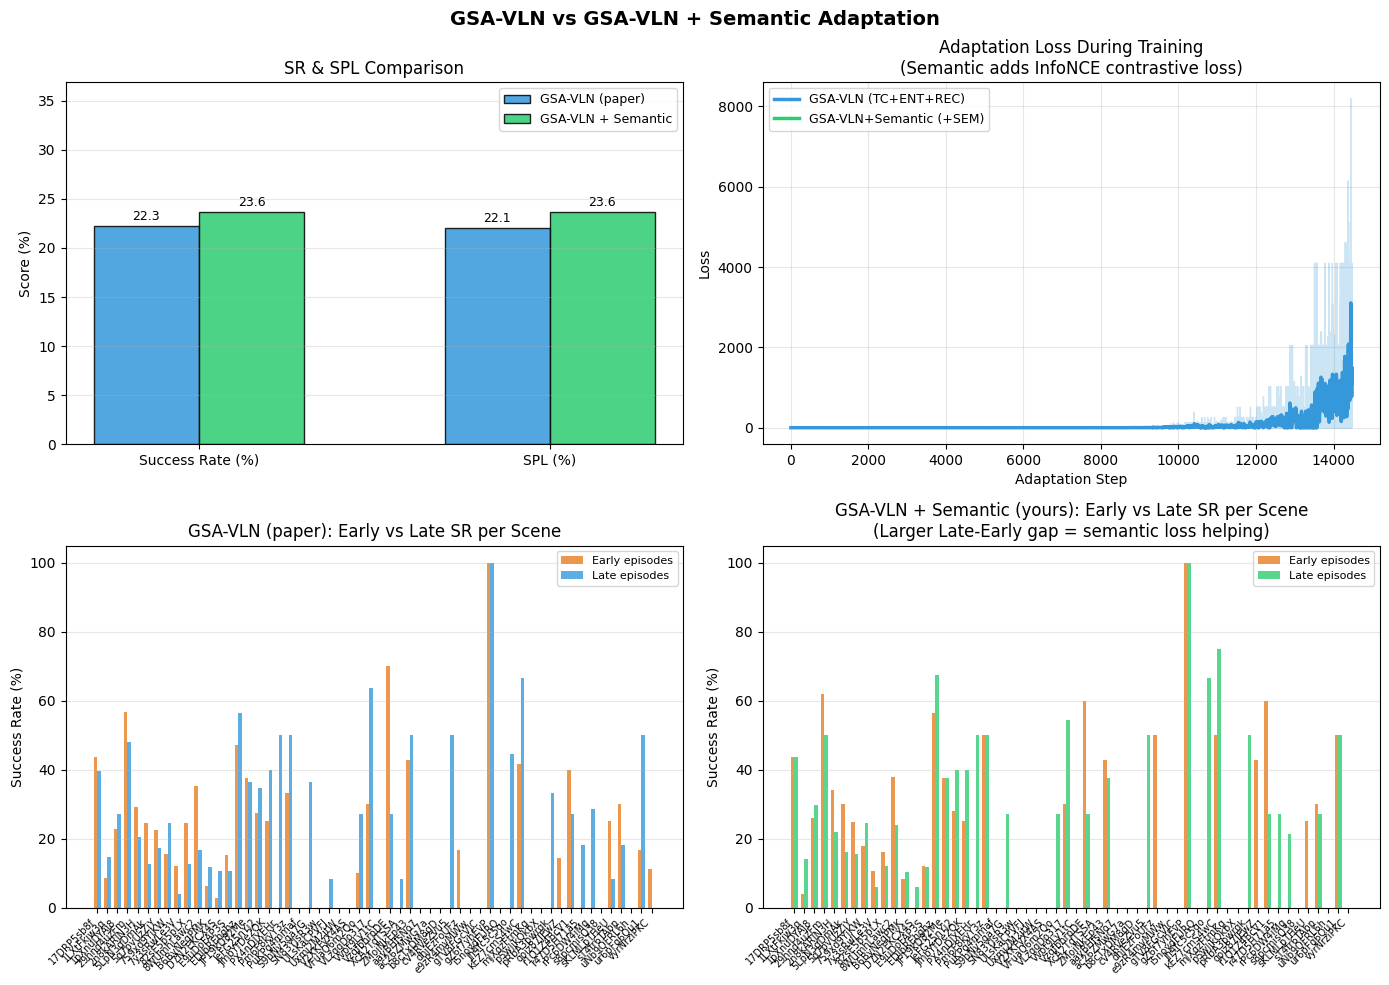

Figure saved: gsa_vln_2way_comparison.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('GSA-VLN vs GSA-VLN + Semantic Adaptation',
             fontsize=14, fontweight='bold')

colors = {'gsa': '#3498db', 'sem': '#2ecc71'}

# ── Plot 1: SR + SPL bar chart ───────────────────────────────────────────────
ax = axes[0, 0]
x  = np.arange(2); w = 0.3
b1 = ax.bar(x - w/2, [sr_gsa, spl_gsa], w,
            label='GSA-VLN (paper)',    color=colors['gsa'], alpha=0.85, edgecolor='black')
b2 = ax.bar(x + w/2, [sr_sem, spl_sem], w,
            label='GSA-VLN + Semantic', color=colors['sem'], alpha=0.85, edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(['Success Rate (%)', 'SPL (%)'])
ax.set_ylabel('Score (%)')
ax.set_title('SR & SPL Comparison')
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(sr_sem, spl_sem, sr_gsa, spl_gsa) * 1.35 + 5)

# ── Plot 2: Adaptation loss curves ───────────────────────────────────────────
ax = axes[0, 1]
def smooth(losses, w=10):
    if len(losses) >= w:
        return list(range(w-1, len(losses))), list(np.convolve(losses, np.ones(w)/w, mode='valid'))
    return list(range(len(losses))), losses

if gsavln_agent.adaptation_losses:
    ax.plot(gsavln_agent.adaptation_losses, color=colors['gsa'], alpha=0.25, linewidth=1)
    xs, ys = smooth(gsavln_agent.adaptation_losses)
    ax.plot(xs, ys, color=colors['gsa'], linewidth=2.5, label='GSA-VLN (TC+ENT+REC)')

if semantic_agent.adaptation_losses:
    ax.plot(semantic_agent.adaptation_losses, color=colors['sem'], alpha=0.25, linewidth=1)
    xs, ys = smooth(semantic_agent.adaptation_losses)
    ax.plot(xs, ys, color=colors['sem'], linewidth=2.5, label='GSA-VLN+Semantic (+SEM)')

ax.set_xlabel('Adaptation Step'); ax.set_ylabel('Loss')
ax.set_title('Adaptation Loss During Training\n(Semantic adds InfoNCE contrastive loss)')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── Plot 3: Early vs Late SR -- GSA-VLN (paper) ─────────────────────────────
ax = axes[1, 0]
summaries_gsa = gsavln_results['scene_summaries']
labels        = [s['scene_id'][:10] for s in summaries_gsa]
early_gsa     = [s['early_success']*100 for s in summaries_gsa]
late_gsa      = [s['late_success'] *100 for s in summaries_gsa]
x2 = np.arange(len(labels)); w2 = 0.35
ax.bar(x2 - w2/2, early_gsa, w2, label='Early episodes', color='#e67e22', alpha=0.8)
ax.bar(x2 + w2/2, late_gsa,  w2, label='Late episodes',  color=colors['gsa'], alpha=0.8)
ax.set_xticks(x2); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Success Rate (%)')
ax.set_title('GSA-VLN (paper): Early vs Late SR per Scene')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

# ── Plot 4: Early vs Late SR -- GSA-VLN + Semantic ──────────────────────────
ax = axes[1, 1]
summaries_sem = semantic_results['scene_summaries']
labels_sem    = [s['scene_id'][:10] for s in summaries_sem]
early_sem     = [s['early_success']*100 for s in summaries_sem]
late_sem      = [s['late_success'] *100 for s in summaries_sem]
x3 = np.arange(len(labels_sem)); w3 = 0.35
ax.bar(x3 - w3/2, early_sem, w3, label='Early episodes', color='#e67e22', alpha=0.8)
ax.bar(x3 + w3/2, late_sem,  w3, label='Late episodes',  color=colors['sem'], alpha=0.8)
ax.set_xticks(x3); ax.set_xticklabels(labels_sem, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Success Rate (%)')
ax.set_title('GSA-VLN + Semantic (yours): Early vs Late SR per Scene\n(Larger Late-Early gap = semantic loss helping)')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('gsa_vln_2way_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: gsa_vln_2way_comparison.png')


## Section 10: What This Comparison Shows


In [ ]:
print("""
2-WAY COMPARISON SUMMARY
=========================

GSA-VLN (paper, Eq.3):
  Adaptation losses -- TC(0.5) + ENT(0.3) + REC(0.2)
  - TC  (Trajectory Consistency):     re-score past actions as pseudo-labels
  - ENT (Entropy Minimization):        TENT-style -- push model toward confident decisions
  - REC (Observation Reconstruction):  predict next observation from current hidden state
  Model: standard -- no room-type-aware graph attention

GSA-VLN + Semantic (your contribution):
  Adaptation losses -- TC(0.4) + ENT(0.25) + REC(0.15) + SEM(0.20)
  - Same TC, ENT, REC as paper, slightly reweighted to make room for SEM
  - SEM (Semantic Contrastive):        InfoNCE loss aligning instruction room-type
    embedding with matching visual viewpoints (positives) vs. non-matching (negatives)
  Model: semantic-aware graph attention that attends to room-type-matching nodes

WHY SEM HELPS:
  The three Eq.3 losses are semantically blind -- they adapt on action distributions
  and observation vectors without understanding WHAT the instruction refers to.
  SEM directly grounds 'go to the bathroom' to bathroom-like visual regions in the
  GraphMap, making the accumulated scene memory semantically queryable rather than
  just a visited-node registry.

HOW TO READ PLOTS:
  - Top-left:  SR and SPL -- your method should score higher on both
  - Top-right: adaptation loss curves -- semantic adds contrastive signal
  - Bottom:    Early vs Late SR per scene -- if your method shows larger
               Late-Early gaps, the semantic loss is accelerating adaptation
""")



2-WAY COMPARISON SUMMARY

GSA-VLN (paper, Eq.3):
  Adaptation losses -- TC(0.5) + ENT(0.3) + REC(0.2)
  - TC  (Trajectory Consistency):     re-score past actions as pseudo-labels
  - ENT (Entropy Minimization):        TENT-style -- push model toward confident decisions
  - REC (Observation Reconstruction):  predict next observation from current hidden state
  Model: standard -- no room-type-aware graph attention

GSA-VLN + Semantic (your contribution):
  Adaptation losses -- TC(0.4) + ENT(0.25) + REC(0.15) + SEM(0.20)
  - Same TC, ENT, REC as paper, slightly reweighted to make room for SEM
  - SEM (Semantic Contrastive):        InfoNCE loss aligning instruction room-type
    embedding with matching visual viewpoints (positives) vs. non-matching (negatives)
  Model: semantic-aware graph attention that attends to room-type-matching nodes

WHY SEM HELPS:
  The three Eq.3 losses are semantically blind -- they adapt on action distributions
  and observation vectors without understanding WH